In [1]:
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats, ndimage
import torch
from genkit import GaussianFlowLinear
from genkit.datasets import fetch_synthetic_data
from genkit.metrics import sliced_wasserstein2
from genkit.nn import MLPModel
from genkit.training import train
from genkit.inspect import model_est_err_curve
from genkit.visitor import CoreMetricsVisitor
from genkit.plotting import PRETTY_RCPARAMS


plt.rcParams.update(PRETTY_RCPARAMS)

In [ ]:
class GaussianFlowLinearUniformT(GaussianFlowLinear):
    """Vanilla uniform t sampler on [t_min, t_max]."""

    def _t(self, n_samples):
        u = torch.rand((n_samples, 1), device=self._device, dtype=self._fdtype)
        return self._t_min + (self._t_max - self._t_min) * u


class GaussianFlowLinearNormalMidT(GaussianFlowLinear):
    """Gaussian t sampler centered at 0.5, clamped to [t_min, t_max]."""

    def __init__(self, *args, t_sigma: float = 0.1, **kwargs):
        super().__init__(*args, **kwargs)
        self._t_sigma = float(t_sigma)

    def _t(self, n_samples):
        z = torch.randn((n_samples, 1), device=self._device, dtype=self._fdtype)
        t = 0.5 + self._t_sigma * z
        return t.clamp(min=self._t_min, max=self._t_max)


class GaussianFlowLinearCosineT(GaussianFlowLinear):
    """Cosine-warped t sampler concentrating more mass near t_min/t_max."""

    def _t(self, n_samples):
        u = torch.rand((n_samples, 1), device=self._device, dtype=self._fdtype)
        w = 1.0 * (1.0 - torch.cos(torch.pi * u))
        return self._t_min + (self._t_max - self._t_min) * w


class GaussianFlowLinearBetaMidT(GaussianFlowLinear):
    """Beta-like (alpha=beta=2) t sampler favoring central times."""

    def _t(self, n_samples):
        u1 = torch.rand((n_samples, 1), device=self._device, dtype=self._fdtype)
        u2 = torch.rand((n_samples, 1), device=self._device, dtype=self._fdtype)
        t = (u1 + u2) * 0.5
        return self._t_min + (self._t_max - self._t_min) * t


FLOW_T_SAMPLER_CLASSES = [
    GaussianFlowLinearUniformT,
    GaussianFlowLinearNormalMidT,
    GaussianFlowLinearCosineT,
    GaussianFlowLinearBetaMidT,
]

dim = 2
n_samples = 20_000
n_steps = 100
batch_size = 1024
n_epochs = 100
lr = 1e-3
use_adamw = True
device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32

x_train, x_val, x_ref = fetch_synthetic_data(
    "unbalanced_bimodal_gaussian",
    n_samples=n_samples,
    dim=dim,
    device=device,
    dtype=fdtype,
)

In [3]:
all_runs = []
for cls in FLOW_T_SAMPLER_CLASSES:

    print("-" * 40)
    print(cls.__name__ + ":")

    net = MLPModel(dim=dim, width=32, depth=2).to(device=device, dtype=fdtype)
    generator = cls(net=net, dim=dim, n_steps=n_steps, t_min=0.001, t_max=0.999, device=device, fdtype=fdtype, idtype=idtype)

    t0 = time.time()
    print("Training...", end="")
    generator, diagnostics = train(
        generator,
        target_data=x_train.clone(),
        batch_size=batch_size,
        n_epochs=n_epochs,
        lr=lr,
        use_adamw=use_adamw,
        device=device,
        visitors=[CoreMetricsVisitor()],
    )
    print(f"Done ({time.time() - t0:.1f} s).")

    all_runs.append({"generator": generator, "diagnostics": diagnostics, })


----------------------------------------
GaussianFlowLinearUniformT:
Training...Done (57.1 s).
----------------------------------------
GaussianFlowLinearNormalMidT:
Training...Done (50.4 s).
----------------------------------------
GaussianFlowLinearCosineT:
Training...Done (53.8 s).
----------------------------------------
GaussianFlowLinearBetaMidT:
Training...Done (52.7 s).


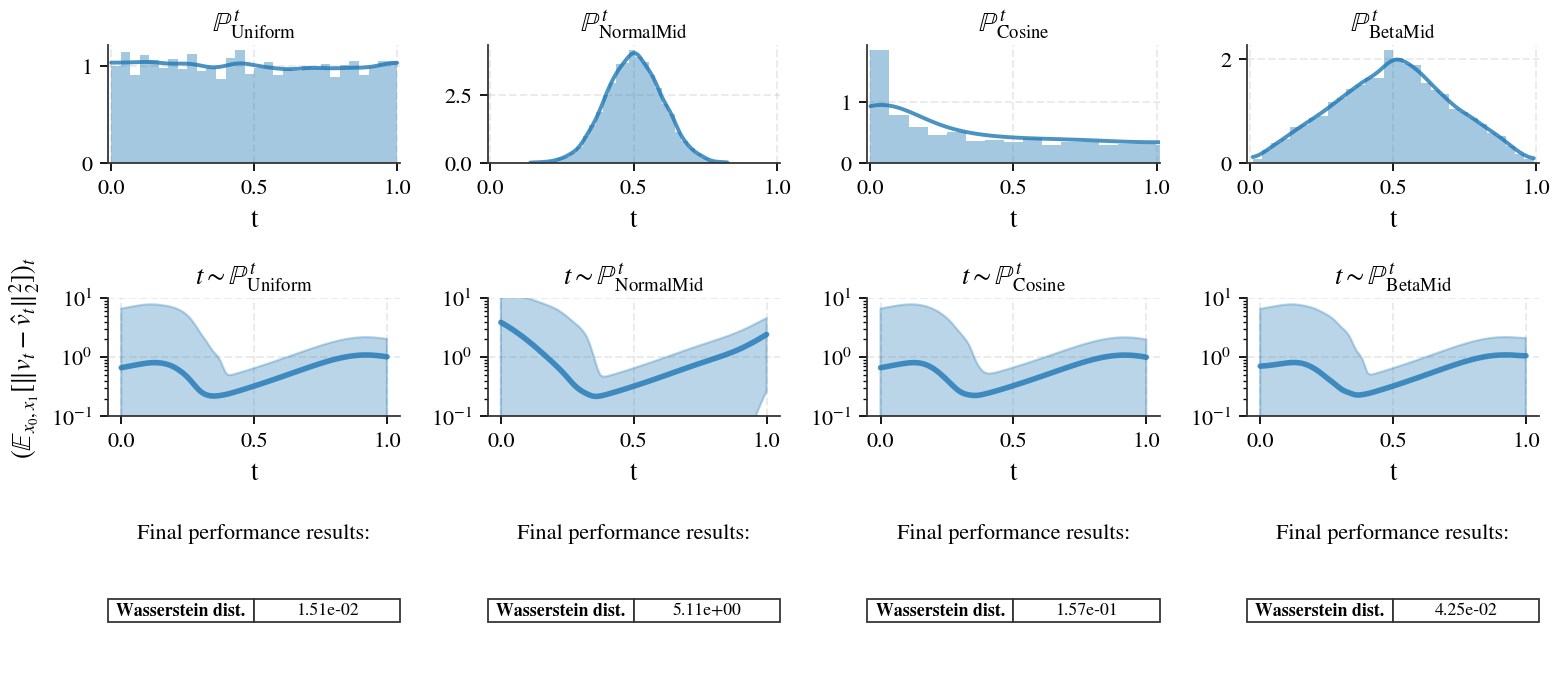

In [13]:
n_samples = 5000
n_cols = len(all_runs)
n_rows = 3

fig, axis = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(2.5 * n_cols, 1.5 * n_rows), squeeze=False)

for i, run in enumerate(all_runs):

    generator = run["generator"]
    tt = generator._t(n_samples).numpy().ravel()

    xx = np.linspace(tt.min(), tt.max(), 100)
    kde = stats.gaussian_kde(tt)
    yy = kde(xx) + kde(-xx) + kde(2 - xx)
    yy /= np.trapezoid(yy, xx)

    axis[0, i].hist(tt, bins=30, density=True, color="tab:blue", alpha=0.4)
    axis[0, i].plot(xx, yy, color="tab:blue", alpha=0.8)
    axis[0, i].set_xlim(-0.01, 1.01)
    axis[0, i].set_xlabel(r"t")
    axis[0, i].set_title(f"$\\mathbb{{P}}^t_{{\\mathrm{{{type(generator).__name__[18:-1]}}}}}$")

    raw_err_t, tt = model_est_err_curve(generator, x_train)
    raw_err_t = np.mean(raw_err_t, axis=-1)
    mean_err_t = np.mean(raw_err_t, axis=-1)
    std_err_t = np.std(raw_err_t, axis=-1)

    axis[1, i].plot(tt, mean_err_t, color="tab:blue", lw=2.5, alpha=0.8)
    axis[1, i].fill_between(tt, mean_err_t - std_err_t, mean_err_t + std_err_t, color="tab:blue", alpha=0.3)
    axis[1, i].set_ylim(0.1, 10.0)
    axis[1, i].set_yscale("log")
    axis[1, i].set_xlabel(r"t")
    axis[1, i].set_title(f"$t \\sim \\mathbb{{P}}^t_{{\\mathrm{{{type(generator).__name__[18:-1]}}}}}$")

    x = generator.sample(n_samples)
    table_data = [["Wasserstein dist.", f"{sliced_wasserstein2(x, x_ref):.2e}"],
                  ]

    tbl = axis[2, i].table(cellText=table_data, loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.0, 1.2)

    for (r, c), cell in tbl.get_celld().items():
        cell.set_linewidth(0.8)
        cell.set_edgecolor("0.2")
        cell.PAD = 0.04
        if c == 0:
            cell.get_text().set_fontweight("semibold")

    axis[2, i].axis("off")
    axis[2, i].set_title("Final performance results:", fontsize=10)

axis[1, 0].set_ylabel(r"$(\mathbb{{E}}_{x_0, x_1}[\|v_t - \hat{v}_t\|_2^2])_t$")
fig.tight_layout()


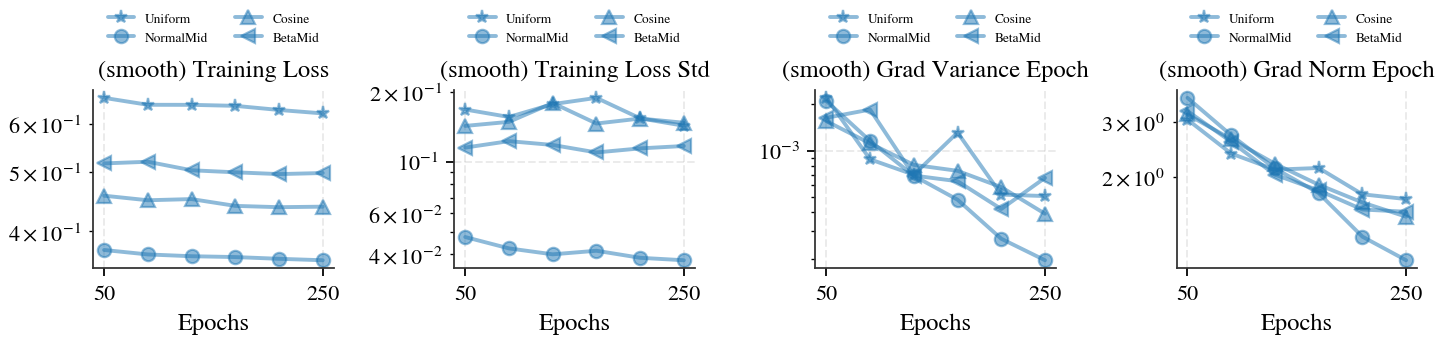

In [14]:
sigma = 10.0
epoch_start = 50
pts_every = 40
n_rows, n_cols = 1, len(all_runs[0]["diagnostics"]["visitors"]["core"])
fig, axis = plt.subplots(n_rows, n_cols, figsize=(2.3 * n_cols, 3.0 * n_rows), squeeze=False)
markers = ['*', 'o', '^', '<', 's']

for marker, run in zip(markers, all_runs):

    generator = run["generator"]
    meta = run["diagnostics"]["visitors"]["core"]

    for i, (metric_name, value) in enumerate(meta.items()):
        xx = np.arange(n_epochs)[epoch_start:][::pts_every]
        yy = ndimage.gaussian_filter1d(value, sigma=sigma)[epoch_start:][::pts_every]
        axis[0, i].plot(xx, yy, color="tab:blue", marker=marker, alpha=0.5,  label=type(generator).__name__[18:-1])
        axis[0, i].set_yscale('log')
        axis[0, i].set_xticks([xx[0], xx[-1]])
        axis[0, i].set_title("(smooth) " + metric_name.replace("_", " ").title(), fontsize=11)
        axis[0, i].set_xlabel("Epochs", fontsize=11)

for ax in axis.ravel():
    ax.legend(ncol=2, fontsize=6, loc="upper center", bbox_to_anchor=(0.5, 1.50))

fig.tight_layout()